In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
import os

from pre_processing import processed_img_preview, img_processing


In [ ]:
IMAGE_PATH = "./dataset/word1.png"
OUTPUT_DIR = "segmented_letters"
IMG_SIZE = 128

os.makedirs(OUTPUT_DIR, exist_ok=True)


In [ ]:
img = cv2.imread(IMAGE_PATH)

if img is None:
    raise ValueError("Image not found")

clean = img_processing(img)

plt.figure(figsize=(8,4))
plt.imshow(clean, cmap="gray")
plt.title("After Pre-processing")
plt.axis("off")
plt.show()


In [ ]:
thresh = cv2.adaptiveThreshold(
    clean, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY_INV,
    15, 4
)

plt.figure(figsize=(8,4))
plt.imshow(thresh, cmap="gray")
plt.title("After Adaptive Threshold")
plt.axis("off")
plt.show()


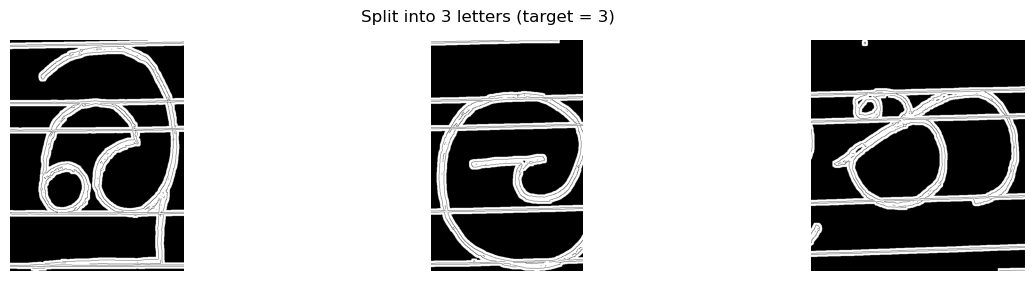

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# ----------------------------
# Utilities
# ----------------------------
def trim_binary(img):
    coords = cv2.findNonZero(img)
    if coords is None:
        return img
    x, y, w, h = cv2.boundingRect(coords)
    return img[y:y+h, x:x+w]


def remove_lines_for_projection(img):
    """
    Create a copy ONLY for projection:
    suppress horizontal lines without touching the original image
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))
    vertical_only = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
    return vertical_only


# ----------------------------
# Main splitter
# ----------------------------
def split_word_exact(
    binary_img,
    num_letters,
    smooth_window=21,
):
    img = trim_binary(binary_img)
    h, w = img.shape

    # --- build projection image (line-robust) ---
    proj_img = remove_lines_for_projection(img)

    projection = np.sum(proj_img == 255, axis=0)

    kernel = np.ones(smooth_window) / smooth_window
    projection = np.convolve(projection, kernel, mode="same")

    # --- find candidate valleys ---
    max_val = np.max(projection)
    valleys = np.where(projection < 0.5 * max_val)[0]

    if len(valleys) == 0:
        return [img]

    # group valleys
    groups = np.split(valleys, np.where(np.diff(valleys) != 1)[0] + 1)
    centers = [int(g.mean()) for g in groups]

    # score valleys by how balanced the split is
    def score(c):
        left_w = c
        right_w = w - c
        return abs(left_w - right_w)

    centers = sorted(centers, key=score)

    # choose N-1 best splits
    splits = sorted(centers[: num_letters - 1])

    # --- split ---
    letters = []
    prev = 0
    for s in splits:
        part = trim_binary(img[:, prev:s])
        if part.size > 0:
            letters.append(part)
        prev = s

    letters.append(trim_binary(img[:, prev:]))

    # safety: merge if still wrong count
    while len(letters) > num_letters:
        a = letters.pop(-2)
        b = letters.pop(-1)
        merged = trim_binary(np.hstack([a, b]))
        letters.append(merged)

    return letters


# ----------------------------
# Preview
# ----------------------------
def preview(binary_img, num_letters):
    letters = split_word_exact(binary_img, num_letters)

    plt.figure(figsize=(15, 3))
    for i, l in enumerate(letters):
        plt.subplot(1, len(letters), i + 1)
        plt.imshow(l, cmap="gray")
        plt.axis("off")

    plt.suptitle(f"Split into {len(letters)} letters (target = {num_letters})")
    plt.show()

    return letters


# ----------------------------
# 🧪 USAGE
# ----------------------------
letters = preview(thresh, num_letters=3)
